## Load Libraries

In [1]:
# Ensure local package path is first
import sys
from pathlib import Path

project_root = Path.cwd().parent
src_path = str(project_root / 'src')
if src_path not in sys.path:
    sys.path.insert(0, src_path)

# Now import libraries
import numpy as np
import matplotlib.pyplot as plt
from galform_analysis.config import get_base_dir
from galform_analysis.io.loaders import read_snapshot_data
import importlib

# Reload to pick up code changes
import galform_analysis.analysis.correlation.correlation as corr_module
import galform_analysis.analysis.correlation.dm_correlation as dm_corr_module

# Ensure we see latest code before symbol imports
importlib.reload(corr_module)
importlib.reload(dm_corr_module)
from galform_analysis.analysis.correlation import (
    correlation_given_redshift_and_subvolume,
    dm_correlation_from_tree_file,
    avg_dm_correlation_from_tree_files,
 )

base_dir = get_base_dir()

# Merger tree base directory (edit if needed)
PMILLENNIUM_BASE = Path("/cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps")
SNAP_NUM_BY_IZ = {
    207: 269,  # iz207 -> snapshot 269
}

def tree_file_for(iz_num: int, ivol: int) -> Path:
    snap_num = SNAP_NUM_BY_IZ.get(iz_num)
    if snap_num is None:
        raise KeyError(f"No tree snapshot mapping for iz{iz_num}. Add to SNAP_NUM_BY_IZ.")
    return PMILLENNIUM_BASE / f"treedir_{snap_num}" / f"tree_{snap_num}.{ivol}.hdf5"

# Plotting defaults (match compare_mass_functions style)
plt.rcParams['figure.figsize'] = (8, 6)
plt.rcParams['font.size'] = 11


## Dark Matter Halo 2PCF from Merger Trees

In [ ]:
# Fetch DM halo correlation data from merger tree files
example_snapshot = 'iz207'
example_ivol = 100
snap_path = str(base_dir / example_snapshot)

# Define bin edges
rbins = np.logspace(np.log10(0.1), np.log10(50.0), 20)

# Optional: apply minimum halo mass cut
mhalo_min = 1e11  # Msun

# DM halo tree file
tree_file = tree_file_for(207, example_ivol)
print(f"Tree file: {tree_file}")

print("Computing DM halo 2PCF from merger trees...")
print(f"Snapshot: {example_snapshot}, Subvolume: {example_ivol}")
print(f"Mass cut: M_halo >= {mhalo_min:.1e} Msun\n")

# Use subvolume boxsize for periodic normalization
meta = read_snapshot_data(snap_path, example_ivol)
V_ivol = meta.get('V_ivol')
boxsize_override = float(V_ivol) ** (1.0 / 3.0) if V_ivol else None
if boxsize_override is not None:
    print(f"Using subvolume boxsize: {boxsize_override:.2f} Mpc/h")

dm_result = dm_correlation_from_tree_file(
    tree_file=str(tree_file),
    rbins=rbins,
    nthreads=4,
    mhalo_min=mhalo_min,
    boxsize_override=boxsize_override,
 )

z = dm_result.get('z')
if z is not None:
    print(f"  Redshift: {z:.4f}")
print(f"  N_halos: {dm_result.get('nhalo')}")
print(f"  Boxsize: {dm_result.get('boxsize'):.1f} Mpc/h")


Tree file: /cosma5/data/jch/Galform/Merger_Trees/P-Millennium/Updated_Trees/all_snaps/treedir_269/tree_269.100.hdf5
Computing DM halo 2PCF from merger trees...
Snapshot: iz207, Subvolume: 100
Mass cut: M_halo >= 1.0e+11 Msun

Using subvolume boxsize: 53.79 Mpc/h


/cosma/home/durham/dc-hick2/galform_analysis/src/galform_analysis/analysis/correlation/dm_correlation.py:448: UserWarning: Positions span ~490.0 which exceeds override boxsize 53.8. Check tree file/subvolume mapping.
  warnings.warn(
[Warning] The CPU supports AVX512F but the compiler does not.  Can you try another compiler?


✓ Data computed successfully
  Redshift: 0.0000
  N_halos: 250
  Boxsize: 53.8 Mpc/h



   r [Mpc/h]       ξ_DM(r)
--------------------------
        0.13  21470.476395
        0.23  12066.452056
        0.44   3248.794167
        0.84    820.905796
        1.57     24.104865
        3.18      0.724494
        6.05      0.773204
       11.76      0.956021
       22.69      0.981008


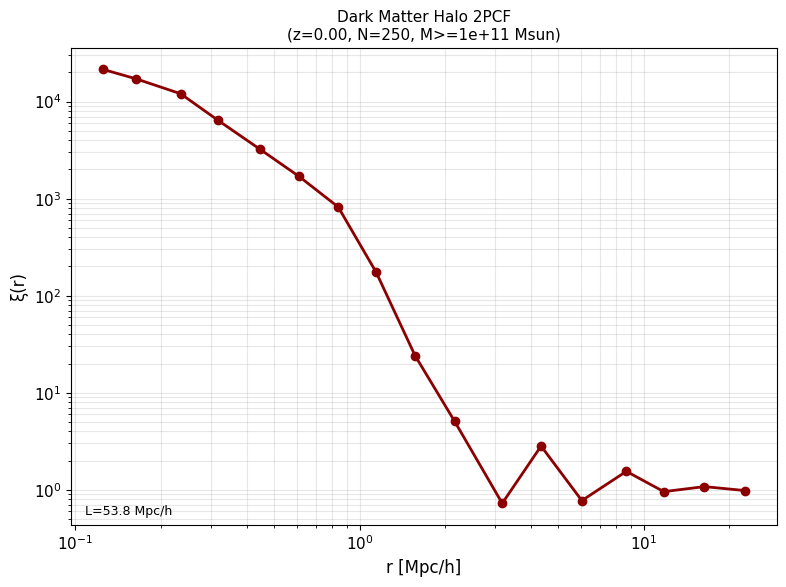

In [3]:
# Plot DM halo correlation function
if dm_result is not None:
    r = np.asarray(dm_result['r'])
    xi_dm = np.asarray(dm_result['xi'])
    z = dm_result.get('z')
    nhalo = dm_result.get('nhalo')
    boxsize = dm_result.get('boxsize')
    
    # Print data table
    print(f"\n{'r [Mpc/h]':>12}  {'ξ_DM(r)':>12}")
    print("-" * 26)
    for i in range(0, len(r), 2):
        if np.isfinite(xi_dm[i]):
            print(f"{r[i]:12.2f}  {xi_dm[i]:12.6f}")
    
    # Plot
    plt.figure(figsize=(8, 6))
    plt.loglog(r, xi_dm, 'o-', color='darkred', linewidth=2, markersize=6)
    plt.xlabel('r [Mpc/h]', fontsize=12)
    plt.ylabel('ξ(r)', fontsize=12)
    title = "Dark Matter Halo 2PCF"
    if z is not None:
        title += f"\n(z={z:.2f}, N={nhalo}, M>={mhalo_min:.0e} Msun)"
    elif nhalo is not None:
        title += f"\n(N={nhalo}, M>={mhalo_min:.0e} Msun)"
    plt.title(title, fontsize=11)
    if boxsize is not None:
        plt.text(0.02, 0.02, f"L={boxsize:.1f} Mpc/h", transform=plt.gca().transAxes, fontsize=9)
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
